In [1]:
#!pip install missingno

In [1]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("/Users/llbm/Desktop/pcd/trab_final/data/df_training_dl.parquet")

df.head(2)

,GameId,PlayId,Yards,Week,Season,A_0,A_1,A_2,A_3,A_4,...,YardLine_12,YardLine_13,YardLine_14,YardLine_15,YardLine_16,YardLine_17,YardLine_18,YardLine_19,YardLine_20,YardLine_21
0,2017090700,20170907000118,8,1,2017,3.35,1.39,0.82,1.36,0.80,...,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0,35.0
1,2017090700,20170907000139,3,1,2017,2.41,2.19,0.92,1.66,1.07,...,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.0


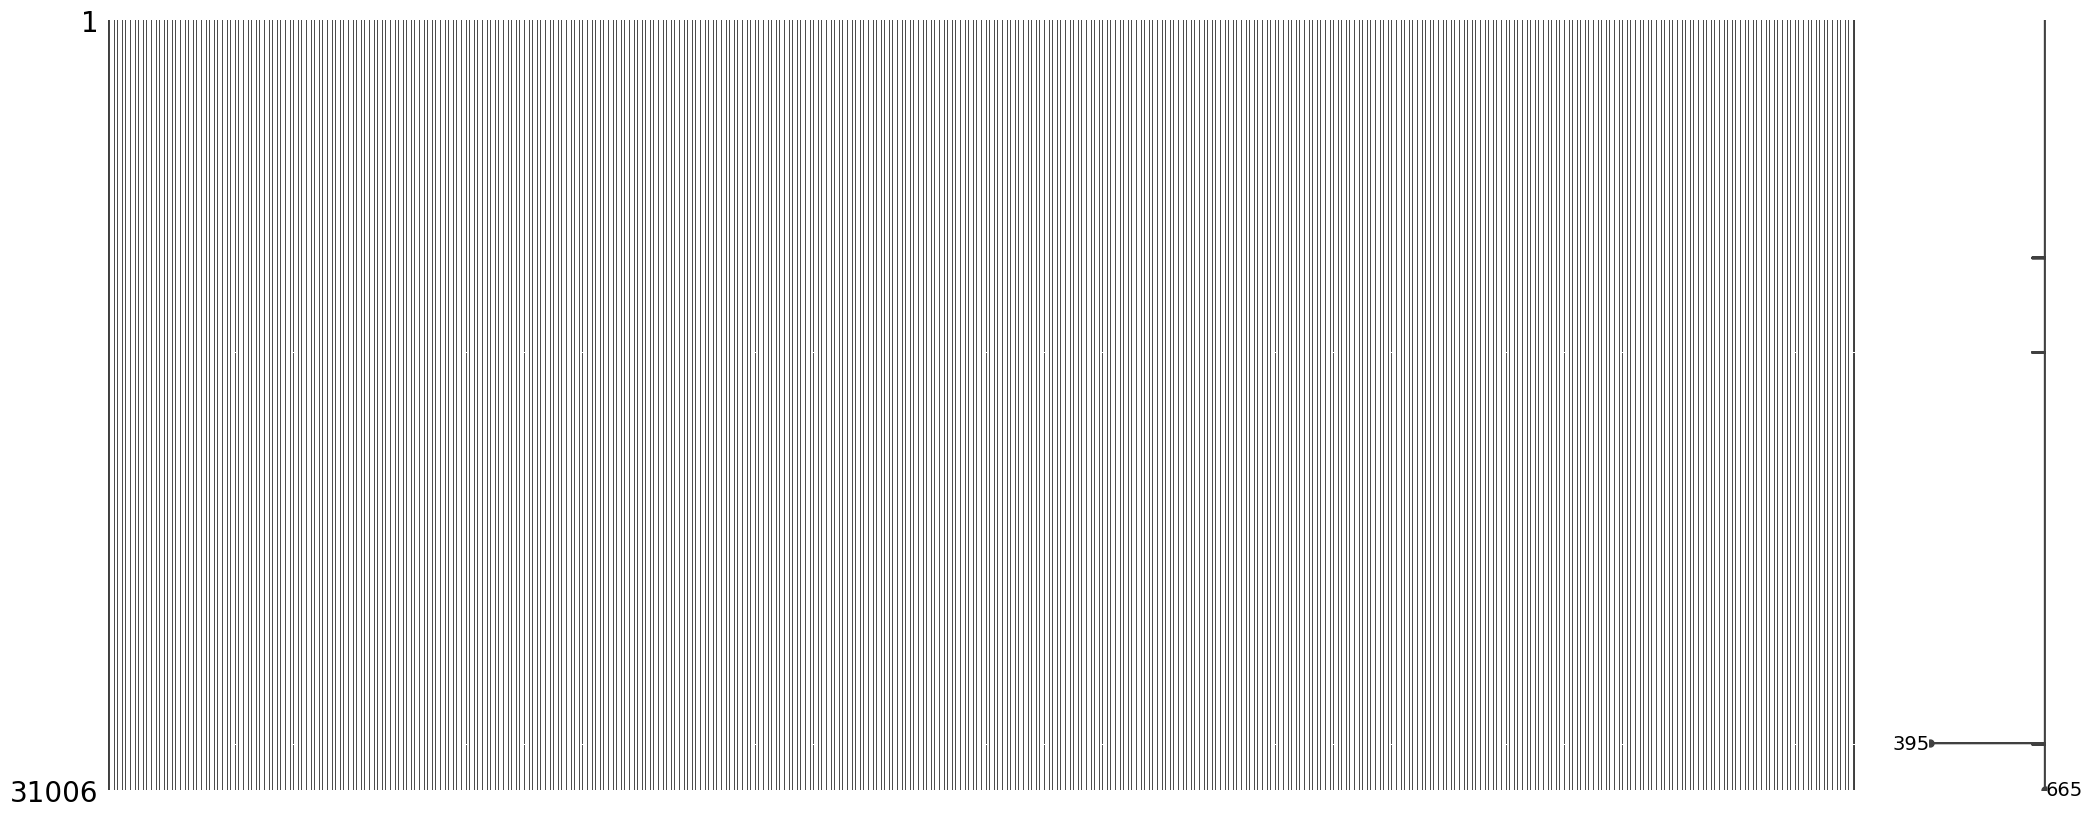

In [14]:
#this graph shows a matrix where the white lines represent the NaNs.
msno.matrix(df)
plt.show()

In [ ]:
#it's what was expected in the flattened dataset

In [7]:
df = df.fillna(0.0)

To begin my graph experimentation, I'll start with a simple architecture:

Each play is modeled as a fully connected directed graph where:
Nodes V: one node per player, |V| = 22
Edges E: all ordered pairs (i, j) where i ≠ j, |E| = 22 × 21 = 462 (fully connected)
Each node is assigned the following features:x, y, dx, dy, vx, vy, dir_x, dir_y, role, etc. Positional features were standardized to always be oriented left-to-right regardless of actual play direction. 
No explicit edge features are used. All inter-player relationships are learned implicitly by the GAT attention mechanism from the node feature pairs (hᵢ, hⱼ).

Architecture-wise, it uses GAT. With a fully connected graph, a single GAT layer already propagates information from every node to every other node. A second layer captures second-order compositions of these interactions. A third layer is optional and subject to validation performance. After the final GAT layer, node embeddings are aggregated into a single play-level representation via: mean pooling captures the average field mood; max pooling captures the most salient individual player signal. The concatenation doubles the representation dimension before the MLP to allow for separation between signals to emerge. A multi-layer perceptron maps the play-level representation to the output distribution. 

Now, why we chose these specifications: well, first of all, in a play, all players interact will all others (either directly - think when a qb throws the ball to a te on yard 90 and they make a touchdown right away; or indirectly - a player sees everyone around him and acts in response to his perceived external inputs, but all players behave like that, so it's a constant feedback loop). Yes, some more with ones than others, but there was no quantitative way to account for that. So our idea was to connect everyone to every other one, and through multi-head GATs, let the model learn the most relevant interactions in each case. Now, about the normalizations and grad clippings, were empirical tools we felt need to add cause we were facing some training instabilities. 

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool

In [9]:
class CRPSLoss(nn.Module):
    def __init__(self, min_yard=-99, max_yard=99, clip_min=-30, clip_max=50):
        super().__init__()
        self.min_yar=min_yard
        self.max_yard=max_yard
        self.clip_min=clip_min
        self.clip_max=clip_max
        self.register_buffer("y_bins", torch.arange(min_yard, max_yard + 1, dtype=torch.float32))

    def forward(self, cdf_pred, y_true):

        if self.training:
            y_true = torch.clamp(y_true, self.clip_min, self.clip_max)
        cdf_true = (self.y_bins[None, :] >= y_true[:, None]).float()
        loss = torch.mean((cdf_pred - cdf_true) ** 2)
        return loss

In [10]:
class NFLGraphDataset(Dataset):
    def __init__(self, df, is_train=True, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        self.df = df.reset_index(drop=True)
        self.is_train = is_train
        adj = np.ones((22, 22)) - np.eye(22)
        edge_index = np.argwhere(adj == 1).T 
        self.edge_index = torch.tensor(edge_index, dtype=torch.long)

        self.global_cols = ['Week', 'Season',
            'Down_0', 'Distance_0', 'AbsYardLine_0', 'DefendersInTheBox_0', 'GameClockPct_0', 'HomeScoreBeforePlay_0', 'VisitorScoreBeforePlay_0', 'OffenseFormation_0', 'FieldPosition_0', 'GameElapsedPct_0',]
        
    def len(self):
        return len(self.df)

    def get(self, idx):
        row = self.df.iloc[idx]
        flip_y = self.is_train and (np.random.rand() > 0.5)
        y_sign = -1.0 if flip_y else 1.0
        is_rusher_arr = np.array([row[f'IsRusher_{i}'] for i in range(22)])
        rusher_idx = int(np.argmax(is_rusher_arr))
        x_rusher = row[f'X_rel_{rusher_idx}']
        y_rusher = row[f'Y_rel_{rusher_idx}'] * y_sign
        node_features = []
        #node feats: x, y, dx, dy, vx, vy, dir_x, dir_y, ori_x, ori_y, weight, height, age, role(3)
        for i in range(22):
            x = row[f'X_rel_{i}']
            y = row[f'Y_rel_{i}'] * y_sign
            dx = x - x_rusher
            dy = y - y_rusher
            v_mag  = row[f'Dis_{i}'] * 10.0
            dir_rad = np.radians(row[f'Dir_{i}'])
            vx = v_mag * np.sin(dir_rad)
            vy = v_mag * np.cos(dir_rad) * y_sign
            dir_x = np.sin(dir_rad)
            dir_y = np.cos(dir_rad) * y_sign
            ori_rad = np.radians(row[f'Orientation_{i}'])
            ori_x = np.sin(ori_rad)
            ori_y = np.cos(ori_rad) * y_sign
            weight = row[f'PlayerWeight_{i}']
            height = row[f'PlayerHeight_{i}']
            age = row[f'PlayerAge_{i}']
            is_rusher = row[f'IsRusher_{i}']
            is_offense = row[f'IsOffense_{i}']
            if is_rusher == 1:
                role = [1, 0, 0]
            elif is_offense == 1:
                role = [0, 1, 0]
            else:
                role = [0, 0, 1]
            node_feat = [x, y, dx, dy, vx, vy, dir_x, dir_y, ori_x, ori_y, weight, height, age] + role
            node_features.append(node_feat)
        x_tensor = torch.tensor(node_features, dtype=torch.float32) 
        global_feat = [row[col] for col in self.global_cols]
        global_tensor = torch.tensor(global_feat, dtype=torch.float32).unsqueeze(0) 

        y_target = torch.tensor(float(row['Yards']), dtype=torch.float32)

        data = Data(x=x_tensor, edge_index=self.edge_index, y=y_target, global_attr=global_tensor)
        return data

In [18]:
class NFLGATModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_heads, global_dim, num_layers=2, dropout=0.15):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()  
        #input layer
        self.convs.append(GATv2Conv(in_channels, hidden_channels, heads=out_heads, dropout=dropout, concat=True))
        self.norms.append(nn.LayerNorm(hidden_channels * out_heads))
        #body: attention + layernorm
        for _ in range(num_layers - 2):
            self.convs.append(GATv2Conv(hidden_channels * out_heads, hidden_channels, heads=out_heads, dropout=dropout, concat=True))
            self.norms.append(nn.LayerNorm(hidden_channels * out_heads))
        #output layer
        self.convs.append(GATv2Conv(hidden_channels * out_heads, hidden_channels, heads=out_heads, dropout=dropout, concat=False))
        self.norms.append(nn.LayerNorm(hidden_channels))
        #readout: mean pool + max pool -> hidden_channels * 2
        post_pool_dim = hidden_channels * 2 + global_dim
        self.mlp = nn.Sequential(
            nn.Linear(post_pool_dim, 256),
            nn.LayerNorm(256),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 199),)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        global_attr = data.global_attr
        if global_attr.dim() == 3:
            global_attr = global_attr.squeeze(1) 
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)  
            x = F.elu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        h_play = torch.cat([x_mean, x_max], dim=1)
        h_combined = torch.cat([h_play, global_attr], dim=1)
        logits = self.mlp(h_combined)
        pmf = F.softmax(logits, dim=-1)
        cdf = torch.cumsum(pmf, dim=-1)
        cdf = torch.clamp(cdf, 0.0, 1.0)

        return cdf

In [19]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss=0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        cdf_pred = model(batch)
        loss = criterion(cdf_pred, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)

In [20]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            cdf_pred = model(batch)
            loss = criterion(cdf_pred, batch.y)
            total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)

In [21]:
def print_cdf_sample(model, loader, device):
    #so we can monitor if any training's actually happening
    model.eval()
    with torch.no_grad():
        batch = next(iter(loader))
        batch = batch.to(device)
        cdf = model(batch)
        sample = cdf[0].cpu().numpy()
        yards = list(range(-99, 100, 10))
        indices = [y + 99 for y in yards]
        print("CDF sample (yards : valor):")
        for yard, idx in zip(yards, indices):
            print(f"    yard {yard:+4d} -> {sample[idx]:.4f}")

In [22]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [25]:
BATCH_SIZE = 64
EPOCHS = 16
LEARNING_RATE = 1e-3

In [26]:
# Training: 2017 + 2018 | Validation: 2018 only
train_df = df[df['Season'].isin([2017, 2018])].reset_index(drop=True)
val_df = df[df['Season'] == 2018].reset_index(drop=True)
print(f"Training examples: {len(train_df)} | Val: {len(val_df)}")

dataset_train = NFLGraphDataset(train_df, is_train=True)
dataset_val = NFLGraphDataset(val_df,is_train=False)
train_loader= DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)
model = NFLGATModel(in_channels=16, hidden_channels=64, out_heads=4, global_dim=12, num_layers=2).to(device)
criterion = CRPSLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
total_steps = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LEARNING_RATE, total_steps=total_steps)

_batch = next(iter(train_loader))
#debug
# print(f"x           : {_batch.x.shape}") #[Batch*22, 11]
# print(f"edge_index  : {_batch.edge_index.shape}")   #[2, Batch*462]
# print(f"y           : {_batch.y.shape}") #[Batch]
# print(f"global_attr : {_batch.global_attr.shape}")#[Batch, 1, 2]

print("\ntraining ongoing")
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | LR: {current_lr:.6f} | Train CRPS: {train_loss:.5f} | Val CRPS: {val_loss:.5f}")
    print_cdf_sample(model, val_loader, device)

Training examples: 23170 | Val: 11270

training ongoing
Epoch 01/16 | LR: 0.000139 | Train CRPS: 0.02215 | Val CRPS: 0.01469
CDF sample (yards : valor):
    yard  -99 -> 0.0001
    yard  -89 -> 0.0011
    yard  -79 -> 0.0022
    yard  -69 -> 0.0035
    yard  -59 -> 0.0045
    yard  -49 -> 0.0054
    yard  -39 -> 0.0064
    yard  -29 -> 0.0074
    yard  -19 -> 0.0097
    yard   -9 -> 0.0162
    yard   +1 -> 0.3793
    yard  +11 -> 0.9669
    yard  +21 -> 0.9801
    yard  +31 -> 0.9880
    yard  +41 -> 0.9916
    yard  +51 -> 0.9935
    yard  +61 -> 0.9949
    yard  +71 -> 0.9965
    yard  +81 -> 0.9977
    yard  +91 -> 0.9990
Epoch 02/16 | LR: 0.000396 | Train CRPS: 0.01416 | Val CRPS: 0.01454
CDF sample (yards : valor):
    yard  -99 -> 0.0001
    yard  -89 -> 0.0008
    yard  -79 -> 0.0017
    yard  -69 -> 0.0025
    yard  -59 -> 0.0033
    yard  -49 -> 0.0041
    yard  -39 -> 0.0050
    yard  -29 -> 0.0061
    yard  -19 -> 0.0075
    yard   -9 -> 0.0106
    yard   +1 -> 0.3516
    ya

We pointed a very distribution way too clustered around mid yards. It seems the model's a bit conservative, as if it said "we'll conquer bet 1 and 10 yards" for every play (exactly the problem reported with models that predict an expected value like a traditional Regression). Such narrow CDF suggests that the softmax is concentrating probability in a few bins. That was the motivation for the following correction:

This is the same architecture, but we add label smoothing on loss function.
The idea is to replace the hard Heaviside curve with a smoothed sigmoid curve around the actual value. Instead of the target going from 0 to 1 in a single bin, it makes a gradual transition within a window of ±k yards. In other words, the model is penalized by narrow distributions directly in the loss function. It works like that: through the smoothing parameter, the width of the smoothing window in yards  controls the slope of the sigmoid around the target.
Smoothing=1 -> almost Heaviside (narrow distribution).
Smoothing=10 -> well-spread distribution.

In [27]:
class SmoothedCRPSLoss(nn.Module):
    def __init__(self, min_yard=-99, max_yard=99,
                 clip_min=-30, clip_max=50, smoothing=5.0):
        super().__init__()
        self.clip_min = clip_min
        self.clip_max = clip_max
        self.smoothing = smoothing
        self.register_buffer("y_bins",
            torch.arange(min_yard, max_yard + 1, dtype=torch.float32))
 
    def forward(self, cdf_pred, y_true):
        if self.training:
            y_true = torch.clamp(y_true, self.clip_min, self.clip_max)
        diff= self.y_bins[None, :] - y_true[:, None]   
        cdf_true = torch.sigmoid(diff / self.smoothing)
        loss = torch.mean((cdf_pred - cdf_true) ** 2)
        return loss

In [28]:
def evaluate(model, loader, criterion, device):
    #evaluation's still done on non-smoothed loss so we can compare with previous model
    model.eval()
    total_loss = 0
    hard_criterion=SmoothedCRPSLoss(smoothing=0.01).to(next(model.parameters()).device)
 
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            cdf_pred = model(batch)
            loss= hard_criterion(cdf_pred, batch.y)
            total_loss += loss.item() * batch.num_graphs
 
    return total_loss / len(loader.dataset)

In [31]:
EPOCHS = 14
SMOOTHING = 2.4 #danault 

In [32]:
# Training: 2017 + 2018 | Validation: 2018 only
train_df = df[df['Season'].isin([2017, 2018])].reset_index(drop=True)
val_df   = df[df['Season'] == 2018].reset_index(drop=True)
print(f"Training examples: {len(train_df)} | Val: {len(val_df)}")

dataset_train = NFLGraphDataset(train_df, is_train=True)
dataset_val = NFLGraphDataset(val_df,   is_train=False)
train_loader= DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False)
model = NFLGATModel(in_channels=16, hidden_channels=64, out_heads=4, global_dim=12, num_layers=2).to(device)
criterion = SmoothedCRPSLoss(smoothing=SMOOTHING).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
total_steps = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LEARNING_RATE, total_steps=total_steps)

_batch = next(iter(train_loader))

print("\ntraining ongoing")
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | LR: {current_lr:.6f} | Train CRPS: {train_loss:.5f} | Val CRPS: {val_loss:.5f}")
    print_cdf_sample(model, val_loader, device)

Training examples: 23170 | Val: 11270

training ongoing
Epoch 01/14 | LR: 0.000168 | Train CRPS: 0.01531 | Val CRPS: 0.01376
CDF sample (yards : valor):
    yard  -99 -> 0.0001
    yard  -89 -> 0.0014
    yard  -79 -> 0.0027
    yard  -69 -> 0.0041
    yard  -59 -> 0.0054
    yard  -49 -> 0.0069
    yard  -39 -> 0.0081
    yard  -29 -> 0.0096
    yard  -19 -> 0.0126
    yard   -9 -> 0.0240
    yard   +1 -> 0.4019
    yard  +11 -> 0.8709
    yard  +21 -> 0.9767
    yard  +31 -> 0.9859
    yard  +41 -> 0.9898
    yard  +51 -> 0.9921
    yard  +61 -> 0.9937
    yard  +71 -> 0.9952
    yard  +81 -> 0.9969
    yard  +91 -> 0.9985
Epoch 02/14 | LR: 0.000485 | Train CRPS: 0.00733 | Val CRPS: 0.01364
CDF sample (yards : valor):
    yard  -99 -> 0.0001
    yard  -89 -> 0.0011
    yard  -79 -> 0.0021
    yard  -69 -> 0.0031
    yard  -59 -> 0.0042
    yard  -49 -> 0.0054
    yard  -39 -> 0.0066
    yard  -29 -> 0.0081
    yard  -19 -> 0.0104
    yard   -9 -> 0.0181
    yard   +1 -> 0.3065
    ya

Things don't seem to have worked as expected.
This might indicate that the more spread-out CDF from smoothing does not correspond to the actual distribution of the data. Yes, the tails are more fit, but at the cost of a less steep increase in center (and from the EDA, we know the true CDF displays a very sharp increase halfway). Thus the CDF without smoothing is not necessarily an architectural problem. In other words, our problem is of precision, not amplitude. 

Also, another thing we could tell is: even with the higher complexity of a GNN, the (baseline) MLP's performance is still higher. Thinking of reasons for that, we thought that maybe topological relations weren't being so well explored with a complete graph: with all possible pairwise interactions set, it was equivalent to a global attention mechanism, and MLP already captures global correlations between the features of all concatenated players.

All those points led us to the next strategy: a graph whose edges introduce game knowledge.

The idea is: define the edges based on most relevant interactions to the development of a running play. These relationships frequently represent ball exchanges, blocking confrontations, and attempts to contain the runner, which constitute the main mechanisms responsible for the success or failure of the play. This is a way to introduce external knowledge to the problem within the database. The relationships we used were:

(C, QB), (QB, RB): represent the exchange of possession that initiates and enables the execution of the run, thus representing the offensive flow.

(LT, DE/EDGE), (LG, DT), (C, NT/DT), (RG, DT), (RT, DE/EDGE): connections between offensive linemen and front defenders represent the direct confrontations that create and close the spaces through which the runner will attempt to advance. The success of a run depends heavily on the outcome of these blocks.

(RB, MLB), (RB, OLB): most frequent matchups after crossing the line of scrimmage.

But first, a few problems we have to solve. In our dataset as it is today, we don't have that level of information (at least not encoded). So we have to recover it from the original dataset, which has a feature named "position" that has this info as strings. After that, we have to infer side information using absolute coordinates (for example, the dataset provides only "higher" positions, like "T", but for my idea, i needed the side as well, like "LT" or "RT").

In [3]:
df_orig=pd.read_parquet("/Users/llbm/Desktop/pcd/trab_final/data/nfl_train.parquet")

In [4]:
#trying to find a join key
df_orig['join_key'] = (df_orig['Season'].astype(int).astype(str) + '_' + 
                       df_orig['Week'].astype(int).astype(str) + '_' + 
                       df_orig['Down'].astype(int).astype(str) + '_' + 
                       df_orig['Distance'].astype(int).astype(str) + '_' +
                       df_orig['Yards'].astype(str))

df['join_key'] = (df['Season'].astype(int).astype(str) + '_' + 
                  df['Week'].astype(int).astype(str) + '_' + 
                  df['Down_0'].astype(int).astype(str) + '_' + 
                  df['Distance_0'].astype(int).astype(str) + '_' +
                  df['Yards'].astype(str))

print(f"original unique keys: {df_orig['join_key'].nunique()}")
print(f"processed unique keys: {df['join_key'].nunique()}")
print(f"common keys: {len(set(df_orig['join_key']) & set(df['join_key']))}")

original unique keys: 9603
processed unique keys: 10553
common keys: 9603


In [5]:
df_orig['join_key'] = (df_orig['Season'].astype(int).astype(str) + '_' +
                       df_orig['Week'].astype(int).astype(str) + '_' +
                       df_orig['Down'].astype(int).astype(str) + '_' +
                       df_orig['Distance'].astype(int).astype(str) + '_' +
                       df_orig['Yards'].astype(str) + '_' +
                       df_orig['HomeScoreBeforePlay'].astype(int).astype(str) + '_' +
                       df_orig['VisitorScoreBeforePlay'].astype(int).astype(str))

df['join_key'] = (df['Season'].astype(int).astype(str) + '_' +
                  df['Week'].astype(int).astype(str) + '_' +
                  df['Down_0'].astype(int).astype(str) + '_' +
                  df['Distance_0'].astype(int).astype(str) + '_' +
                  df['Yards'].astype(str) + '_' +
                  df['HomeScoreBeforePlay_0'].astype(int).astype(str) + '_' +
                  df['VisitorScoreBeforePlay_0'].astype(int).astype(str))

print(f"original duplicates: {df_orig['join_key'].duplicated().sum()}")
print(f"duplicates processed: {df['join_key'].duplicated().sum()}")
print(f"keys in common: {len(set(df_orig['join_key']) & set(df['join_key']))}")

original duplicates: 3887
duplicates processed: 4341
keys in common: 24199


In [6]:
df_kaggle = pd.read_csv("/Users/llbm/Desktop/pcd/trab_final/data/train.csv")
nossas_colunas = list(df.columns)  
print("shape:", df_kaggle.shape)
print("\nColunas:")
print(df_kaggle.columns.tolist())

/var/folders/qb/ldt_bc3j77969pkfrmpl2bbc0000gn/T/ipykernel_19701/2140369303.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df_kaggle = pd.read_csv("/Users/llbm/Desktop/pcd/trab_final/data/train.csv")


shape: (682154, 49)

Colunas:
['GameId', 'PlayId', 'Team', 'X', 'Y', 'S', 'A', 'Dis', 'Orientation', 'Dir', 'NflId', 'DisplayName', 'JerseyNumber', 'Season', 'YardLine', 'Quarter', 'GameClock', 'PossessionTeam', 'Down', 'Distance', 'FieldPosition', 'HomeScoreBeforePlay', 'VisitorScoreBeforePlay', 'NflIdRusher', 'OffenseFormation', 'OffensePersonnel', 'DefendersInTheBox', 'DefensePersonnel', 'PlayDirection', 'TimeHandoff', 'TimeSnap', 'Yards', 'PlayerHeight', 'PlayerWeight', 'PlayerBirthDate', 'PlayerCollegeName', 'Position', 'HomeTeamAbbr', 'VisitorTeamAbbr', 'Week', 'Stadium', 'Location', 'StadiumType', 'Turf', 'GameWeather', 'Temperature', 'Humidity', 'WindSpeed', 'WindDirection']


In [7]:
print(df_kaggle['Position'].unique())

['SS' 'DE' 'ILB' 'FS' 'CB' 'DT' 'WR' 'TE' 'T' 'QB' 'RB' 'G' 'C' 'OLB' 'NT'
 'FB' 'MLB' 'LB' 'OT' 'S' 'OG' 'HB' 'DB' 'DL' 'SAF']


In [8]:
pos_map = df_kaggle[['NflId', 'Position']].drop_duplicates()
print(f"Unique NflIds: {pos_map['NflId'].nunique()}")
print(f"Lines in the mapping: {len(pos_map)}")
#sanity checks

Unique NflIds: 2570
Lines in the mapping: 2570


In [9]:
#mapping NflId -> Position
pos_map = df_kaggle[['NflId', 'Position']].drop_duplicates().set_index('NflId')['Position'].to_dict()
#retrieves position for each of the 22 players per play
for i in range(22):
    df[f'PositionStr_{i}'] = df[f'NflId_{i}'].map(pos_map)
#checks coverage
missing = df[[f'PositionStr_{i}' for i in range(22)]].isnull().sum().sum()
total = len(df) * 22
print(f"Positions retrieved: {total - missing}/{total} ({100*(total-missing)/total:.1f}%)")
print(df[[f'PositionStr_{i}' for i in range(22)]].head(3))

Positions retrieved: 682100/682132 (100.0%)
  PositionStr_0 PositionStr_1 PositionStr_2 PositionStr_3 PositionStr_4  \
0            RB            WR            TE             T             T   
1            RB            WR            TE             T             T   
2            RB            WR            TE             T             T   

  PositionStr_5 PositionStr_6 PositionStr_7 PositionStr_8 PositionStr_9  ...  \
0            QB            WR            WR             G             C  ...   
1            QB            WR            WR             G             C  ...   
2            QB            WR            WR             G             C  ...   

  PositionStr_12 PositionStr_13 PositionStr_14 PositionStr_15 PositionStr_16  \
0             DE             DE            ILB             FS             DE   
1             DE             DE            ILB             FS             DE   
2             DE             DE            ILB             FS             DE   

  PositionStr

In [10]:
df_kaggle_play = df_kaggle[df_kaggle['PlayId'] == df_kaggle['PlayId'].iloc[0]]
print(df_kaggle_play[['Position', 'X', 'Y', 'Team', 'PossessionTeam', 'PlayDirection']].to_string())

   Position      X      Y  Team PossessionTeam PlayDirection
0        SS  73.91  34.84  away             NE          left
1        DE  74.67  32.64  away             NE          left
2        DE  74.00  33.20  away             NE          left
3       ILB  71.46  27.70  away             NE          left
4        FS  69.32  35.42  away             NE          left
5        DE  75.06  24.00  away             NE          left
6        CB  74.11  16.64  away             NE          left
7        CB  73.37  18.73  away             NE          left
8        SS  56.63  26.90  away             NE          left
9        CB  73.35  38.83  away             NE          left
10       DT  74.15  28.90  away             NE          left
11       WR  75.82  17.56  home             NE          left
12       TE  74.78  33.21  home             NE          left
13        T  75.43  32.41  home             NE          left
14        T  75.90  25.12  home             NE          left
15       QB  79.76  29.4

In [11]:
# From the original dataset, we extracted absolute positions (X, Y) and positions (T, G, DE, etc.) per player per play.
# Using Y relative to the center and PlayDirection, we inferred specific tactical positions: LT, RT, LG, RG, DE-L, DE-R.*
# Join by NflId with the processed df to add these refined positions.
# *The center (C) is the pivot of Oline. Players with Y > Y_center are to the left of the center, players with Y < Y_center are to the right.

In [12]:
print("Original GameId sample:", df_kaggle['GameId'].head(3).tolist())
print("Processed GameId sample:", df['GameId'].head(3).tolist())

Original GameId sample: [2017090700, 2017090700, 2017090700]
Processed GameId sample: [2017090700, 2017090700, 2017090700]


In [13]:
#checks if GameId + PlayId is unique in Kaggle
print(df_kaggle.groupby('GameId')['PlayId'].nunique().describe())
#and in the processed data
print(df[['GameId', 'PlayId']].drop_duplicates().groupby('GameId')['PlayId'].nunique().describe())
#checks if PlayId is unique within each GameId in both systems
print("\nOriginal PlayId unique per game:", (df_kaggle.groupby(['GameId', 'PlayId']).size() == 22).all())

count    688.000000
mean      45.068314
std        6.658633
min       25.000000
25%       41.000000
50%       45.000000
75%       50.000000
max       85.000000
Name: PlayId, dtype: float64
count    688.000000
mean      45.066860
std        6.659631
min       25.000000
25%       41.000000
50%       45.000000
75%       50.000000
max       85.000000
Name: PlayId, dtype: float64

Original PlayId unique per game: True


In [14]:
# Creates an ordinal index of plays within each game on Kaggle
df_kaggle_plays = df_kaggle[['GameId', 'PlayId']].drop_duplicates()
df_kaggle_plays['play_order'] = df_kaggle_plays.groupby('GameId').cumcount()
# Does the same in the processed data
df_plays = df[['GameId', 'PlayId']].drop_duplicates()
df_plays['play_order'] = df_plays.groupby('GameId').cumcount()
# Checks if the number of plays per game matches
kaggle_counts = df_kaggle_plays.groupby('GameId')['PlayId'].count()
proc_counts = df_plays.groupby('GameId')['PlayId'].count()

diff = (kaggle_counts - proc_counts).abs()
print(f"Games with different counts: {(diff > 0).sum()}")
print(f"Games in common: {len(set(df_kaggle['GameId']) & set(df['GameId']))}")

Games with different counts: 1
Games in common: 688


In [15]:
kaggle_counts = df_kaggle[['GameId', 'PlayId']].drop_duplicates().groupby('GameId')['PlayId'].count()
proc_counts = df[['GameId', 'PlayId']].drop_duplicates().groupby('GameId')['PlayId'].count()
diff = (kaggle_counts - proc_counts).abs()
problem = diff[diff > 0]
print(problem)

GameId
2018122302    1
Name: PlayId, dtype: int64


In [16]:
#Remove GameId = 2018122302 from both datasets
#Create an ordinal index of play within each game in both datasets -->

In [17]:
GAME_DELETE = 2018122302
#remove the problematic game
df_kaggle_clean = df_kaggle[df_kaggle['GameId'] != GAME_DELETE].copy()
df_clean = df[df['GameId'] != GAME_DELETE].copy()
# Create an ordinal index of the play within each game
# Kaggle: one row per player, so we get unique plays first
df_kaggle_plays = df_kaggle_clean[['GameId', 'PlayId']].drop_duplicates().copy()
df_kaggle_plays = df_kaggle_plays.sort_values(['GameId', 'PlayId']).reset_index(drop=True)
df_kaggle_plays['play_order'] = df_kaggle_plays.groupby('GameId').cumcount()
# Processed: one line per play
df_plays = df_clean[['GameId', 'PlayId']].copy()
df_plays = df_plays.sort_values(['GameId', 'PlayId']).reset_index(drop=True)
df_plays['play_order'] = df_plays.groupby('GameId').cumcount()


print(f"Plays on Kaggle: {len(df_kaggle_plays)}")
print(f"Plays unprocessed: {len(df_plays)}")

#confirm that they now match
kaggle_counts = df_kaggle_plays.groupby('GameId')['PlayId'].count()
proc_counts = df_plays.groupby('GameId')['PlayId'].count()
diff = (kaggle_counts - proc_counts).abs()
print(f"Games with different counts after deletion: {(diff > 0).sum()}")

Plays on Kaggle: 30966
Plays unprocessed: 30966
Games with different counts after deletion: 0


In [18]:
# Join por GameId + play_order for mapping PlayId_kaggle → PlayId_processado

In [19]:
# Join by GameId + play_order
play_map = df_kaggle_plays.merge( 
df_plays.rename(columns={'PlayId': 'PlayId_proc'}), 
on=['GameId', 'play_order'], 
how='inner'
).rename(columns={'PlayId': 'PlayId_kaggle'})

print(f"Mapped plays: {len(play_map)}")
print(play_map.head(3))

# Check its 1:1
assert play_map['PlayId_kaggle'].nunique() == len(play_map), "Duplicate in PlayId_kaggle"
assert play_map['PlayId_proc'].nunique() == len(play_map), "Duplicate in PlayId_proc"
print("Join 1:1 confirmed")

Mapped plays: 30966
       GameId   PlayId_kaggle  play_order     PlayId_proc
0  2017090700  20170907000118           0  20170907000118
1  2017090700  20170907000139           1  20170907000139
2  2017090700  20170907000189           2  20170907000189
Join 1:1 confirmed


In [20]:
#now that we did the join, we'll infer side info

In [21]:
def infer_tactical_position(group):
    play_dir = group['PlayDirection'].iloc[0]
    center = group[group['Position'] == 'C']
    if len(center) == 0:
        return group 
    y_center = center['Y'].iloc[0]

    if play_dir == 'right':
        left_side = lambda y: y > y_center
    else:
        left_side = lambda y: y < y_center
    result = group.copy()

    for idx, row in group.iterrows():
        pos = row['Position']
        y = row['Y']
        if pos == 'T':
            result.at[idx, 'Position'] = 'LT' if left_side(y) else 'RT'
        elif pos == 'G':
            result.at[idx, 'Position'] = 'LG' if left_side(y) else 'RG'
        elif pos == 'DE':
            result.at[idx, 'Position'] = 'DE-L' if left_side(y) else 'DE-R'
    return result
#apply and verify
df_kaggle_tactical = (df_kaggle_clean.groupby('PlayId', group_keys=False).apply(infer_tactical_position))
print(df_kaggle_tactical['Position'].value_counts().head(15))

Position
CB     74385
WR     71404
DT     47149
TE     44178
OLB    43291
C      32942
FS     32677
RB     31323
QB     31112
SS     26749
LT     25968
RG     24103
RT     23470
ILB    23029
LG     22184
Name: count, dtype: int64


/var/folders/qb/ldt_bc3j77969pkfrmpl2bbc0000gn/T/ipykernel_19701/332805311.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_kaggle_tactical = (df_kaggle_clean.groupby('PlayId', group_keys=False).apply(infer_tactical_position))


In [22]:
print(df_kaggle_tactical['Position'].value_counts().to_string())

Position
CB      74385
WR      71404
DT      47149
TE      44178
OLB     43291
C       32942
FS      32677
RB      31323
QB      31112
SS      26749
LT      25968
RG      24103
RT      23470
ILB     23029
LG      22184
DE-L    21111
DE-R    20966
LB      13933
MLB     13247
NT      10738
OT       8356
G        8243
T        6773
OG       4945
FB       4787
DB       4756
DE       4682
S        2630
DL       1134
HB        968
SAF        19


In [23]:
#no center plays
plays_sem_center = df_kaggle_clean.groupby('PlayId').apply(
    lambda g: (g['Position'] == 'C').sum() == 0)
print(f"Plays sem center: {plays_sem_center.sum()}")
print(f"Total de plays: {plays_sem_center.shape[0]}")

Plays sem center: 3431
Total de plays: 30966


/var/folders/qb/ldt_bc3j77969pkfrmpl2bbc0000gn/T/ipykernel_19701/1337243938.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plays_sem_center = df_kaggle_clean.groupby('PlayId').apply(


In [24]:
#taking one as a sample to understand what's going on
play_sem_center = plays_sem_center[plays_sem_center].index[0]
print(df_kaggle_clean[df_kaggle_clean['PlayId'] == play_sem_center][['Position', 'X', 'Y', 'Team']].to_string())

     Position      X      Y  Team
2222      OLB  83.86  36.79  away
2223       DE  82.19  32.92  away
2224       NT  84.92  34.93  away
2225       CB  77.74  33.63  away
2226       CB  80.19  11.07  away
2227       SS  71.88  24.34  away
2228       DT  84.49  33.33  away
2229      MLB  81.86  34.79  away
2230      OLB  84.71  29.27  away
2231       FS  80.07  36.22  away
2232      OLB  83.49  38.39  away
2233        G  85.38  34.43  home
2234       TE  83.73  37.95  home
2235        G  84.01  33.08  home
2236        T  84.83  36.98  home
2237       WR  86.00  32.72  home
2238       QB  90.11  32.79  home
2239       TE  84.05  37.66  home
2240        T  82.72  32.60  home
2241       WR  80.86  12.01  home
2242       OG  81.71  34.03  home
2243       RB  88.57  33.52  home


In [25]:
sem_center = df_kaggle_clean[df_kaggle_clean['PlayId'].isin(plays_sem_center[plays_sem_center].index)]

tem_og = sem_center.groupby('PlayId').apply(lambda g: (g['Position'] == 'OG').any())
tem_g  = sem_center.groupby('PlayId').apply(lambda g: (g['Position'] == 'G').any())
print(f"Plays without C, with OG: {tem_og.sum()}")
print(f"Plays without C, without OG, with G: {(~tem_og & tem_g).sum()}")
print(f"Plays without C, without OG, without G: {(~tem_og & ~tem_g).sum()}")

Plays without C, with OG: 766
Plays without C, without OG, with G: 2665
Plays without C, without OG, without G: 0


/var/folders/qb/ldt_bc3j77969pkfrmpl2bbc0000gn/T/ipykernel_19701/2483705169.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tem_og = sem_center.groupby('PlayId').apply(lambda g: (g['Position'] == 'OG').any())
/var/folders/qb/ldt_bc3j77969pkfrmpl2bbc0000gn/T/ipykernel_19701/2483705169.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tem_g  = sem_center.groupby('PlayId').apply(lambda g: (g['Position'] 

In [26]:
#it displays center as other positions that assume this spot. its either C or OG or G

In [27]:
def get_center_y(group):
    off = group[
        group['Team'] ==
        group[group['NflId'] == group['NflId'].iloc[0]]['Team'].iloc[0]]

    for pos in ['C', 'OG', 'G']:
        candidates = group[group['Position'] == pos]
        if len(candidates) > 0:
            if len(candidates) == 1:
                return candidates['Y'].iloc[0]
            else:
                #multiple candidates: choose the most central player
                off_y_mean = group[
                    group['Team'] == group.iloc[0]['Team']]['Y'].mean()
                idx = (candidates['Y'] - off_y_mean).abs().idxmin()
                return candidates.loc[idx, 'Y']
    return None

In [28]:
def infer_tactical_position_v2(group):
    play_dir = group['PlayDirection'].iloc[0]
    #offense
    possession = group['PossessionTeam'].iloc[0]
    y_center = get_center_y(group)
    if y_center is None:
        return group

    if play_dir == 'right':
        left_side = lambda y: y > y_center
    else:
        left_side = lambda y: y < y_center

    result = group.copy()

    for idx, row in group.iterrows():
        pos = row['Position']
        y = row['Y']
        if pos in ['T', 'OT']:
            result.at[idx, 'Position'] = ('LT' if left_side(y) else 'RT')

        elif pos in ['G', 'OG']:
            result.at[idx, 'Position'] = ('LG' if left_side(y) else 'RG')

        elif pos == 'DE':
            result.at[idx, 'Position'] = ('DE-L' if left_side(y) else 'DE-R')
    return result

df_kaggle_tactical = (df_kaggle_clean.groupby('PlayId', group_keys=False).apply(infer_tactical_position_v2))
print(df_kaggle_tactical['Position'].value_counts().to_string())

Position
CB      74385
WR      71404
DT      47149
TE      44178
OLB     43291
RG      33201
LT      33155
C       32942
FS      32677
RT      31412
RB      31323
QB      31112
SS      26749
LG      26274
DE-R    23382
DE-L    23377
ILB     23029
LB      13933
MLB     13247
NT      10738
FB       4787
DB       4756
S        2630
DL       1134
HB        968
SAF        19


/var/folders/qb/ldt_bc3j77969pkfrmpl2bbc0000gn/T/ipykernel_19701/2787133070.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_kaggle_tactical = (df_kaggle_clean.groupby('PlayId', group_keys=False).apply(infer_tactical_position_v2))


In [30]:
#(PlayId_kaggle, NflId) -> Position 
tactical_map = df_kaggle_tactical[['PlayId', 'NflId', 'Position']].copy()
tactical_map = tactical_map.rename(columns={'PlayId': 'PlayId_kaggle', 'Position': 'TacticalPosition'})

tactical_map = tactical_map.merge(
    play_map[['PlayId_kaggle', 'PlayId_proc']],
    on='PlayId_kaggle',
    how='inner'
)

In [31]:
long_parts = []
for i in range(22):
    part = df_clean[['PlayId', f'NflId_{i}']].copy()
    part.columns = ['PlayId_proc', 'NflId']
    part['player_idx'] = i
    long_parts.append(part)

df_long = pd.concat(long_parts, ignore_index=True)
#join
df_long = df_long.merge(tactical_map[['PlayId_proc', 'NflId', 'TacticalPosition']],on=['PlayId_proc', 'NflId'],how='left')
#pivot back to wide
df_tactical_wide = df_long.pivot_table(index='PlayId_proc',columns='player_idx',values='TacticalPosition',aggfunc='first')
df_tactical_wide.columns = [f'TacticalPos_{i}' for i in range(22)]
df_tactical_wide = df_tactical_wide.reset_index().rename(columns={'PlayId_proc': 'PlayId'})
#join 
df_clean = df_clean.merge(df_tactical_wide, on='PlayId', how='left')

missing = df_clean[[f'TacticalPos_{i}' for i in range(22)]].isnull().sum().sum()
total = len(df_clean) * 22
print(f"{total - missing}/{total} ({100*(total-missing)/total:.1f}%)")
print(df_clean[[f'TacticalPos_{i}' for i in range(22)]].head(3))

681220/681252 (100.0%)
  TacticalPos_0 TacticalPos_1 TacticalPos_2 TacticalPos_3 TacticalPos_4  \
0            RB            WR            TE            RT            LT   
1            RB            WR            TE            RT            LT   
2            RB            WR            TE            RT            LT   

  TacticalPos_5 TacticalPos_6 TacticalPos_7 TacticalPos_8 TacticalPos_9  ...  \
0            QB            WR            WR            RG             C  ...   
1            QB            WR            WR            RG             C  ...   
2            QB            WR            WR            RG             C  ...   

  TacticalPos_12 TacticalPos_13 TacticalPos_14 TacticalPos_15 TacticalPos_16  \
0           DE-R           DE-R            ILB             FS           DE-L   
1           DE-R           DE-R            ILB             FS           DE-L   
2           DE-R           DE-R            ILB             FS           DE-L   

  TacticalPos_17 TacticalPos_18 Ta

In [ ]:
#finally now that all info's correct, add to our dataset

In [32]:
cols_to_drop = [c for c in df_clean.columns if c.startswith('TacticalPos_')]
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')
#merge
df_clean = df_clean.merge(df_tactical_wide, on='PlayId', how='left')
#sanity check
missing = df_clean[[f'TacticalPos_{i}' for i in range(22)]].isnull().sum().sum()
total = len(df_clean) * 22
print(f"All done?: {total - missing}/{total} ({100*(total-missing)/total:.1f}%)")
print(df_clean[[f'TacticalPos_{i}' for i in range(22)]].head(3))

All done?: 681220/681252 (100.0%)
  TacticalPos_0 TacticalPos_1 TacticalPos_2 TacticalPos_3 TacticalPos_4  \
0            RB            WR            TE            RT            LT   
1            RB            WR            TE            RT            LT   
2            RB            WR            TE            RT            LT   

  TacticalPos_5 TacticalPos_6 TacticalPos_7 TacticalPos_8 TacticalPos_9  ...  \
0            QB            WR            WR            RG             C  ...   
1            QB            WR            WR            RG             C  ...   
2            QB            WR            WR            RG             C  ...   

  TacticalPos_12 TacticalPos_13 TacticalPos_14 TacticalPos_15 TacticalPos_16  \
0           DE-R           DE-R            ILB             FS           DE-L   
1           DE-R           DE-R            ILB             FS           DE-L   
2           DE-R           DE-R            ILB             FS           DE-L   

  TacticalPos_17 Tactic

Now we can build a graph based on position and interaction knowledge

In [33]:
def build_tactical_edges_level1(row):
    #returns a bidirectional edge_index array representing key
    #interactions between offensive and defensive players.

    #map positions to player indices
    pos_to_idx = {}
    for i in range(22):
        pos = row[f'TacticalPos_{i}']
        if pos not in pos_to_idx:
            pos_to_idx[pos] = []
        pos_to_idx[pos].append(i)

    #player coordinates used for distance calculations
    positions = np.array([[row[f'X_rel_{i}'], row[f'Y_rel_{i}']] for i in range(22)])

    edges = set()
    def add_edge(i, j):
        edges.add((i, j))
        edges.add((j, i))

    def closest(src_idx, tgt_indices):
        if not tgt_indices:
            return None
        dists = [np.linalg.norm(positions[src_idx] - positions[t]) for t in tgt_indices]
        return tgt_indices[np.argmin(dists)]

    #Center + Quarterback
    for c in pos_to_idx.get('C', []):
        for qb in pos_to_idx.get('QB', []):
            add_edge(c, qb)

    #Quarterback + Running Back
    for qb in pos_to_idx.get('QB', []):
        for rb in pos_to_idx.get('RB', []):
            add_edge(qb, rb)

    #Left Tackle + Left Defensive End
    for lt in pos_to_idx.get('LT', []):
        for de in pos_to_idx.get('DE-L', []):
            add_edge(lt, de)

    #Right Tackle + Right Defensive End
    for rt in pos_to_idx.get('RT', []):
        for de in pos_to_idx.get('DE-R', []):
            add_edge(rt, de)

    dts = (pos_to_idx.get('DT', []) + pos_to_idx.get('NT', []))

    for lg in pos_to_idx.get('LG', []):
        tgt = closest(lg, dts)
        if tgt is not None:
            add_edge(lg, tgt)

    for c in pos_to_idx.get('C', []):
        tgt = closest(c, dts)
        if tgt is not None:
            add_edge(c, tgt)

    for rg in pos_to_idx.get('RG', []):
        tgt = closest(rg, dts)
        if tgt is not None:
            add_edge(rg, tgt)

    # Running Back + all linebackers
    lbs = (pos_to_idx.get('MLB', []) + pos_to_idx.get('OLB', []) +
        pos_to_idx.get('ILB', []) + pos_to_idx.get('LB', []))

    for rb in pos_to_idx.get('RB', []):
        for lb in lbs:
            add_edge(rb, lb)

    if not edges:
        return np.zeros((2, 0), dtype=np.int64)

    src, dst = zip(*edges)
    return np.array([list(src), list(dst)], dtype=np.int64)


#test
sample = df_clean.iloc[0]
edges = build_tactical_edges_level1(sample)
print(f"Edges in sample play: {edges.shape[1]}")
print(f"Unique tactical relationships: {edges.shape[1] // 2}")

#edge count distribution
n_edges = df_clean.apply(lambda row: build_tactical_edges_level1(row).shape[1], axis=1)

print(f"\nEdges per play — "
    f"min: {n_edges.min()}, "
    f"max: {n_edges.max()}, "
    f"mean: {n_edges.mean():.1f}")

Edges in sample play: 18
Unique tactical relationships: 9

Edges per play — min: 2, max: 42, mean: 19.3


In [34]:
n_edges = df_clean.apply(lambda row: build_tactical_edges_level1(row).shape[1], axis=1)

few_edges = df_clean[n_edges <= 4]
print(f"Plays with <= 4 edges: {len(few_edges)}")
#inspect the tactical positions of one example
sample_few = few_edges.iloc[0]
positions = [sample_few[f'TacticalPos_{i}'] for i in range(22)]

print("Positions:", positions)
print("Edges:", build_tactical_edges_level1(sample_few))

Plays with <= 4 edges: 12
Positions: ['FB', 'WR', 'TE', 'RG', 'LG', 'C', 'RG', 'QB', 'WR', 'WR', 'LG', 'OLB', 'ILB', 'CB', 'CB', 'ILB', 'FS', 'CB', 'OLB', 'DE-R', 'DE-L', 'FS']
Edges: [[7 5]
 [5 7]]


In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool

In [36]:
class CRPSLoss(nn.Module):
    def __init__(self, min_yard=-99, max_yard=99, clip_min=-30, clip_max=50):
        super().__init__()
        self.clip_min = clip_min
        self.clip_max = clip_max
        self.register_buffer("y_bins", torch.arange(min_yard, max_yard + 1, dtype=torch.float32))

    def forward(self, cdf_pred, y_true):
        if self.training:
            y_true = torch.clamp(y_true, self.clip_min, self.clip_max)
        cdf_true = (self.y_bins[None, :] >= y_true[:, None]).float()
        loss = torch.mean((cdf_pred - cdf_true) ** 2)
        return loss

In [37]:
class NFLGraphDataset(Dataset):
    def __init__(self, df, is_train=True, transform=None, pre_transform=None):
        super().__init__(None, transform, pre_transform)
        self.df = df.reset_index(drop=True)
        self.is_train = is_train

        self.global_cols = [
            'Week', 'Season',
            'Down_0', 'Distance_0', 'AbsYardLine_0', 'YardLine_0',
            'DefendersInTheBox_0', 'GameClockPct_0',
            'HomeScoreBeforePlay_0', 'VisitorScoreBeforePlay_0',
            'OffenseFormation_0', 'FieldPosition_0', 'GameElapsedPct_0',
            'DefensePersonnel_0', 'OffensePersonnel_0', 'PossessionTeam_0',
        ]  # global_dim = 16

    def len(self):
        return len(self.df)

    def get(self, idx):
        row = self.df.iloc[idx]
        flip_y  = self.is_train and (np.random.rand() > 0.5)
        y_sign  = -1.0 if flip_y else 1.0
        is_rusher_arr = np.array([row[f'IsRusher_{i}'] for i in range(22)])
        rusher_idx    = int(np.argmax(is_rusher_arr))
        x_rusher = row[f'X_rel_{rusher_idx}']
        y_rusher = row[f'Y_rel_{rusher_idx}'] * y_sign

        node_features = []
        for i in range(22):
            x = row[f'X_rel_{i}']
            y = row[f'Y_rel_{i}'] * y_sign
            dx = x - x_rusher
            dy = y - y_rusher
            v_mag = row[f'Dis_{i}'] * 10.0
            dir_rad = np.radians(row[f'Dir_{i}'])
            vx = v_mag * np.sin(dir_rad)
            vy = v_mag * np.cos(dir_rad) * y_sign
            dir_x = np.sin(dir_rad)
            dir_y = np.cos(dir_rad) * y_sign
            ori_rad = np.radians(row[f'Orientation_{i}'])
            ori_x = np.sin(ori_rad)
            ori_y = np.cos(ori_rad) * y_sign
            weight = row[f'PlayerWeight_{i}']
            height = row[f'PlayerHeight_{i}']
            age = row[f'PlayerAge_{i}']
            s = row[f'S_{i}']
            a = row[f'A_{i}']
            nfl_id = row[f'NflId_{i}']
            nfl_id_rusher = row[f'NflIdRusher_{i}']
            position = row[f'Position_{i}']
            team = row[f'Team_{i}']
            is_rusher  = row[f'IsRusher_{i}']
            is_offense = row[f'IsOffense_{i}']
            if is_rusher == 1:
                role = [1, 0, 0]
            elif is_offense == 1:
                role = [0, 1, 0]
            else:
                role = [0, 0, 1]
            node_feat = [x, y, dx, dy, vx, vy, dir_x, dir_y,
                ori_x, ori_y, weight, height, age, s, a,
                nfl_id, nfl_id_rusher, position, team] + role
            node_features.append(node_feat)
        x_tensor = torch.tensor(node_features, dtype=torch.float32) 
        
        pos_to_idx = {}
        for i in range(22):
            pos = row[f"TacticalPos_{i}"]
            if pos not in pos_to_idx:
                pos_to_idx[pos] = []
            pos_to_idx[pos].append(i)

        positions = np.array([[row[f"X_rel_{i}"], row[f"Y_rel_{i}"]] for i in range(22)])

        def closest(src_idx, tgt_indices):
            if not tgt_indices:
                return None
            dists = [np.linalg.norm(positions[src_idx] - positions[t]) for t in tgt_indices]
            return tgt_indices[int(np.argmin(dists))]

        edges = set()
        def add_edge(i, j):
            edges.add((i, j))
            edges.add((j, i))

        # C <-> QB
        for c in pos_to_idx.get("C", []):
            for qb in pos_to_idx.get("QB", []):
                add_edge(c, qb)

        # QB <-> RB
        for qb in pos_to_idx.get("QB", []):
            for rb in pos_to_idx.get("RB", []):
                add_edge(qb, rb)

        # LT <-> DE-L
        for lt in pos_to_idx.get("LT", []):
            for de in pos_to_idx.get("DE-L", []):
                add_edge(lt, de)

        # RT <-> DE-R
        for rt in pos_to_idx.get("RT", []):
            for de in pos_to_idx.get("DE-R", []):
                add_edge(rt, de)

        # LG, C, RG <-> DT/NT closest
        dts = pos_to_idx.get("DT", []) + pos_to_idx.get("NT", [])
        for pos_key in ["LG", "C", "RG"]:
            for src_idx in pos_to_idx.get(pos_key, []):
                tgt = closest(src_idx, dts)
                if tgt is not None:
                    add_edge(src_idx, tgt)

        # RB <-> all LB
        lbs = (pos_to_idx.get("MLB", []) + pos_to_idx.get("OLB", []) +
               pos_to_idx.get("ILB", []) + pos_to_idx.get("LB", []))
        for rb in pos_to_idx.get("RB", []):
            for lb in lbs:
                add_edge(rb, lb)

        if edges:
            src_list, dst_list = zip(*edges)
            edge_index = torch.tensor([list(src_list), list(dst_list)], dtype=torch.long)
        else:
            edge_index = torch.zeros((2, 0), dtype=torch.long)

        global_feat = [row[col] for col in self.global_cols]
        global_tensor = torch.tensor(global_feat, dtype=torch.float32).unsqueeze(0) 
        y_target = torch.tensor(float(row['Yards']), dtype=torch.float32)

        return Data(x=x_tensor, edge_index=edge_index,
                    y=y_target, global_attr=global_tensor)

In [38]:
#pretty much same architecture
class NFLGATModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_heads,
                 global_dim, num_layers=2, dropout=0.15):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        self.convs.append(GATv2Conv(in_channels, hidden_channels, heads=out_heads, dropout=dropout, concat=True))
        self.norms.append(nn.LayerNorm(hidden_channels * out_heads))
        
        for _ in range(num_layers - 2):
            self.convs.append(GATv2Conv(hidden_channels * out_heads, hidden_channels, heads=out_heads, dropout=dropout, concat=True))
            self.norms.append(nn.LayerNorm(hidden_channels * out_heads))

        self.convs.append(GATv2Conv(hidden_channels * out_heads, hidden_channels, heads=out_heads, dropout=dropout, concat=False))
        self.norms.append(nn.LayerNorm(hidden_channels))

        mlp_in = hidden_channels * 2 + global_dim  
        self.mlp = nn.Sequential(
            nn.Linear(mlp_in, 256),
            nn.LayerNorm(256),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 199),)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        global_attr = data.global_attr
        if global_attr.dim() == 3:
            global_attr = global_attr.squeeze(1)  

        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = F.elu(x)
            if i < self.num_layers - 1:
                x = F.dropout(x, p=self.dropout, training=self.training)

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        h_play = torch.cat([x_mean, x_max], dim=1)
        h_combined = torch.cat([h_play, global_attr], dim=1)
        logits = self.mlp(h_combined)
        pmf = F.softmax(logits, dim=-1)
        cdf = torch.cumsum(pmf, dim=-1)
        cdf = torch.clamp(cdf, 0.0, 1.0)

        return cdf

In [39]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        cdf_pred = model(batch)
        loss = criterion(cdf_pred, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)

In [40]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            cdf_pred = model(batch)
            loss = criterion(cdf_pred, batch.y)
            total_loss += loss.item() * batch.num_graphs

    return total_loss / len(loader.dataset)

In [41]:
def print_cdf_sample(model, loader, device):
    model.eval()
    with torch.no_grad():
        batch  = next(iter(loader))
        batch  = batch.to(device)
        cdf    = model(batch)
        sample = cdf[0].cpu().numpy()
        yards   = list(range(-99, 100, 10))
        indices = [y + 99 for y in yards]
        print(" CDF sample (yards:):")
        for yard, idx in zip(yards, indices):
            print(f" yard {yard:+4d} -> {sample[idx]:.4f}")

In [42]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [45]:
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-3

In [49]:
#same split
last_weeks = [15, 16, 17]
train_df = df_clean[~df_clean['Week'].isin(last_weeks)].reset_index(drop=True)
val_df = df_clean[ df_clean['Week'].isin(last_weeks)].reset_index(drop=True)
#same evrything
dataset_train = NFLGraphDataset(train_df, is_train=True)
dataset_val = NFLGraphDataset(val_df, is_train=False)
train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)
_batch = next(iter(train_loader))

model = NFLGATModel(in_channels=22, hidden_channels=64, out_heads=4, global_dim=16, num_layers=2).to(device)
criterion = CRPSLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
total_steps = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LEARNING_RATE, total_steps=total_steps)

print("\ntraining ongoing")
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | LR: {current_lr:.6f} | "
          f"Train CRPS: {train_loss:.5f} | Val CRPS: {val_loss:.5f}")
    print_cdf_sample(model, val_loader, device)


training ongoing
Epoch 01/20 | LR: 0.000104 | Train CRPS: 0.02106 | Val CRPS: 0.01353
 CDF sample (yards:):
 yard  -99 -> 0.0002
 yard  -89 -> 0.0016
 yard  -79 -> 0.0028
 yard  -69 -> 0.0041
 yard  -59 -> 0.0055
 yard  -49 -> 0.0066
 yard  -39 -> 0.0077
 yard  -29 -> 0.0091
 yard  -19 -> 0.0116
 yard   -9 -> 0.0184
 yard   +1 -> 0.3114
 yard  +11 -> 0.9430
 yard  +21 -> 0.9827
 yard  +31 -> 0.9886
 yard  +41 -> 0.9912
 yard  +51 -> 0.9932
 yard  +61 -> 0.9945
 yard  +71 -> 0.9958
 yard  +81 -> 0.9973
 yard  +91 -> 0.9988
Epoch 02/20 | LR: 0.000280 | Train CRPS: 0.01404 | Val CRPS: 0.01348
 CDF sample (yards:):
 yard  -99 -> 0.0001
 yard  -89 -> 0.0010
 yard  -79 -> 0.0018
 yard  -69 -> 0.0027
 yard  -59 -> 0.0036
 yard  -49 -> 0.0044
 yard  -39 -> 0.0054
 yard  -29 -> 0.0065
 yard  -19 -> 0.0081
 yard   -9 -> 0.0114
 yard   +1 -> 0.2487
 yard  +11 -> 0.9390
 yard  +21 -> 0.9845
 yard  +31 -> 0.9898
 yard  +41 -> 0.9924
 yard  +51 -> 0.9942
 yard  +61 -> 0.9956
 yard  +71 -> 0.9968
 y

Still, the performance is not as good as we expected it to be. We seem to be stuck in this crps. Let's do an experiment to check if it's worth insisting on GNN or not let's compare a simple mlp to an simple gnn.

In [ ]:
#I ran this code once but it takes a bit so i just copied the results i needed for the conclusions and commented it so it does not run automatically on run all
# class CRPSLoss(nn.Module):
#     def __init__(self, min_yard=-99, max_yard=99, clip_min=-30, clip_max=50):
#         super().__init__()
#         self.clip_min = clip_min
#         self.clip_max = clip_max
#         self.register_buffer("y_bins", torch.arange(min_yard, max_yard + 1, dtype=torch.float32))

#     def forward(self, cdf_pred, y_true):
#         if self.training:
#             y_true = torch.clamp(y_true, self.clip_min, self.clip_max)
#         cdf_true = (self.y_bins[None, :] >= y_true[:, None]).float()
#         return torch.mean((cdf_pred - cdf_true) ** 2)

# def extract_node_features(row, y_sign):
#     is_rusher_arr = np.array([row[f'IsRusher_{i}'] for i in range(22)])
#     rusher_idx = int(np.argmax(is_rusher_arr))
#     x_rusher = row[f'X_rel_{rusher_idx}']
#     y_rusher = row[f'Y_rel_{rusher_idx}'] * y_sign

#     node_features = []
#     for i in range(22):
#         x = row[f'X_rel_{i}']
#         y = row[f'Y_rel_{i}'] * y_sign
#         dx = x - x_rusher
#         dy = y - y_rusher

#         v_mag = row[f'Dis_{i}'] * 10.0
#         dir_rad = np.radians(row[f'Dir_{i}'])
#         vx = v_mag * np.sin(dir_rad)
#         vy = v_mag * np.cos(dir_rad) * y_sign
#         dir_x = np.sin(dir_rad)
#         dir_y = np.cos(dir_rad) * y_sign
#         ori_rad = np.radians(row[f'Orientation_{i}'])
#         ori_x = np.sin(ori_rad)
#         ori_y = np.cos(ori_rad) * y_sign
#         weight = row[f'PlayerWeight_{i}']
#         height = row[f'PlayerHeight_{i}']
#         age = row[f'PlayerAge_{i}']
#         s = row[f'S_{i}']
#         a = row[f'A_{i}']
#         nfl_id = row[f'NflId_{i}']
#         nfl_id_rusher = row[f'NflIdRusher_{i}']
#         position = row[f'Position_{i}']
#         team = row[f'Team_{i}']
#         is_rusher = row[f'IsRusher_{i}']
#         is_offense = row[f'IsOffense_{i}']
#         if is_rusher == 1:
#             role = [1, 0, 0]
#         elif is_offense == 1:
#             role = [0, 1, 0]
#         else:
#             role = [0, 0, 1]
#         node_feat = [x, y, dx, dy, vx, vy, dir_x, dir_y, ori_x, ori_y, weight, height, age, s, a, nfl_id, nfl_id_rusher, position, team] + role
#         node_features.append(node_feat)

#     return np.array(node_features, dtype=np.float32) 


# GLOBAL_COLS = [
#     'Week', 'Season',
#     'Down_0', 'Distance_0', 'AbsYardLine_0', 'YardLine_0',
#     'DefendersInTheBox_0', 'GameClockPct_0',
#     'HomeScoreBeforePlay_0', 'VisitorScoreBeforePlay_0',
#     'OffenseFormation_0', 'FieldPosition_0', 'GameElapsedPct_0',
#     'DefensePersonnel_0', 'OffensePersonnel_0', 'PossessionTeam_0',
# ]

# #mlp with limited features
# #features: 22 nodes × 22 features = 484 concatenated + 16 global = 500

# class RestrictedFlatDataset(Dataset):
#     def __init__(self, df, is_train=True):
#         self.df       = df.reset_index(drop=True)
#         self.is_train = is_train

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         y_sign = -1.0 if (self.is_train and np.random.rand() > 0.5) else 1.0

#         nodes = extract_node_features(row, y_sign)       
#         flat = nodes.flatten()                          
#         glob = np.array([row[col] for col in GLOBAL_COLS], dtype=np.float32)  
#         x = np.concatenate([flat, glob])             
#         y = float(row['Yards'])
#         return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


# class RestrictedMLP(nn.Module):
#     def __init__(self, input_dim=500, dropout=0.15):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 256),
#             nn.LayerNorm(256),
#             nn.ELU(),
#             nn.Dropout(dropout),
#             nn.Linear(256, 512),
#             nn.LayerNorm(512),
#             nn.ELU(),
#             nn.Dropout(dropout),
#             nn.Linear(512, 199),)

#     def forward(self, x):
#         logits = self.net(x)
#         pmf = F.softmax(logits, dim=-1)
#         cdf = torch.cumsum(pmf, dim=-1)
#         return torch.clamp(cdf, 0.0, 1.0)

# #GNN without message passing
# #embed each node with individual MLP, then pooling, then final MLP, no information exchange between nodes

# class NoMessagePassingDataset(PyGDataset):
#     def __init__(self, df, is_train=True, transform=None, pre_transform=None):
#         super().__init__(None, transform, pre_transform)
#         self.df = df.reset_index(drop=True)
#         self.is_train = is_train

#     def len(self):
#         return len(self.df)

#     def get(self, idx):
#         row = self.df.iloc[idx]
#         y_sign = -1.0 if (self.is_train and np.random.rand() > 0.5) else 1.0
#         nodes = extract_node_features(row, y_sign)
#         x_tensor = torch.tensor(nodes, dtype=torch.float32)  # [22, 22]

#         glob = [row[col] for col in GLOBAL_COLS]
#         global_tensor = torch.tensor(glob, dtype=torch.float32).unsqueeze(0)
#         y_target = torch.tensor(float(row['Yards']), dtype=torch.float32)
#         #no edge index
#         return Data(x=x_tensor, edge_index=torch.zeros((2, 0), dtype=torch.long),
#                     y=y_target, global_attr=global_tensor)


# class NoMessagePassingModel(nn.Module):
#     def __init__(self, in_channels=22, hidden=64, global_dim=16, dropout=0.15):
#         super().__init__()
#         #MLP by node
#         self.node_mlp = nn.Sequential(
#             nn.Linear(in_channels, hidden * 2),
#             nn.LayerNorm(hidden * 2),
#             nn.ELU(),
#             nn.Dropout(dropout),
#             nn.Linear(hidden * 2, hidden),
#             nn.LayerNorm(hidden),
#             nn.ELU(),)

#         #MLP final: mean+max pooling + global
#         mlp_in = hidden * 2 + global_dim  # 128 + 16 = 144
#         self.mlp = nn.Sequential(
#             nn.Linear(mlp_in, 256),
#             nn.LayerNorm(256),
#             nn.ELU(),
#             nn.Dropout(dropout),
#             nn.Linear(256, 512),
#             nn.LayerNorm(512),
#             nn.ELU(),
#             nn.Dropout(dropout),
#             nn.Linear(512, 199),)

#     def forward(self, data):
#         x, batch = data.x, data.batch
#         global_attr = data.global_attr
#         if global_attr.dim() == 3:
#             global_attr = global_attr.squeeze(1)
#         #independent embeddings
#         x = self.node_mlp(x) 
#         x_mean = global_mean_pool(x, batch)
#         x_max = global_max_pool(x, batch)
#         h_play = torch.cat([x_mean, x_max], dim=1)
#         h_combined = torch.cat([h_play, global_attr], dim=1)
#         logits = self.mlp(h_combined)
#         pmf = F.softmax(logits, dim=-1)
#         cdf = torch.cumsum(pmf, dim=-1)
#         return torch.clamp(cdf, 0.0, 1.0)

# def train_flat(model, loader, optimizer, scheduler, criterion, device):
#     model.train()
#     total_loss = 0
#     for x_batch, y_batch in loader:
#         x_batch, y_batch = x_batch.to(device), y_batch.to(device)
#         optimizer.zero_grad()
#         cdf_pred = model(x_batch)
#         loss = criterion(cdf_pred, y_batch)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()
#         scheduler.step()
#         total_loss += loss.item() * len(x_batch)
#     return total_loss / len(loader.dataset)


# def eval_flat(model, loader, criterion, device):
#     model.eval()
#     total_loss = 0
#     with torch.no_grad():
#         for x_batch, y_batch in loader:
#             x_batch, y_batch = x_batch.to(device), y_batch.to(device)
#             cdf_pred = model(x_batch)
#             loss = criterion(cdf_pred, y_batch)
#             total_loss += loss.item() * len(x_batch)
#     return total_loss / len(loader.dataset)


# def train_pyg(model, loader, optimizer, scheduler, criterion, device):
#     model.train()
#     total_loss = 0
#     for batch in loader:
#         batch = batch.to(device)
#         optimizer.zero_grad()
#         cdf_pred = model(batch)
#         loss = criterion(cdf_pred, batch.y)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()
#         scheduler.step()
#         total_loss += loss.item() * batch.num_graphs
#     return total_loss / len(loader.dataset)


# def eval_pyg(model, loader, criterion, device):
#     model.eval()
#     total_loss = 0
#     with torch.no_grad():
#         for batch in loader:
#             batch = batch.to(device)
#             cdf_pred = model(batch)
#             loss = criterion(cdf_pred, batch.y)
#             total_loss += loss.item() * batch.num_graphs
#     return total_loss / len(loader.dataset)

# BATCH_SIZE = 64
# EPOCHS = 6
# LEARNING_RATE = 1e-3
# last_weeks = [15, 16, 17]
# train_df = df_clean[~df_clean['Week'].isin(last_weeks)].reset_index(drop=True)
# val_df = df_clean[ df_clean['Week'].isin(last_weeks)].reset_index(drop=True)
# criterion = CRPSLoss().to(device)

# print("MLP")
# ds_train_flat = RestrictedFlatDataset(train_df, is_train=True)
# ds_val_flat = RestrictedFlatDataset(val_df, is_train=False)
# loader_train_flat = DataLoader(ds_train_flat, batch_size=BATCH_SIZE, shuffle=True)
# loader_val_flat = DataLoader(ds_val_flat, batch_size=BATCH_SIZE, shuffle=False)

# model_d1 = RestrictedMLP(input_dim=500).to(device)
# opt_d1 = torch.optim.Adam(model_d1.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# sched_d1 = torch.optim.lr_scheduler.OneCycleLR(opt_d1, max_lr=LEARNING_RATE, total_steps=EPOCHS * len(loader_train_flat))
# best_d1 = np.inf
# for epoch in range(1, EPOCHS + 1):
#     tr = train_flat(model_d1, loader_train_flat, opt_d1, sched_d1, criterion, device)
#     va = eval_flat(model_d1, loader_val_flat, criterion, device)
#     if va < best_d1:
#         best_d1 = va
#     if epoch % 5 == 0 or epoch == 1:
#         print(f"Epoch {epoch:02d}/{EPOCHS} | Train: {tr:.5f} | Val: {va:.5f}")

# print(f"\nX: {best_d1:.5f}")

# print("GNN")
# ds_train_nmp = NoMessagePassingDataset(train_df, is_train=True)
# ds_val_nmp = NoMessagePassingDataset(val_df, is_train=False)
# loader_train_nmp = PyGDataLoader(ds_train_nmp, batch_size=BATCH_SIZE, shuffle=True)
# loader_val_nmp = PyGDataLoader(ds_val_nmp, batch_size=BATCH_SIZE, shuffle=False)
# model_d2  = NoMessagePassingModel(in_channels=22, hidden=64, global_dim=16).to(device)
# opt_d2 = torch.optim.Adam(model_d2.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
# sched_d2  = torch.optim.lr_scheduler.OneCycleLR(opt_d2, max_lr=LEARNING_RATE, total_steps=EPOCHS * len(loader_train_nmp))

# best_d2 = np.inf
# for epoch in range(1, EPOCHS + 1):
#     tr = train_pyg(model_d2, loader_train_nmp, opt_d2, sched_d2, criterion, device)
#     va = eval_pyg(model_d2, loader_val_nmp, criterion, device)
#     if va < best_d2:
#         best_d2 = va
#     if epoch % 5 == 0 or epoch == 1:
#         print(f"Epoch {epoch:02d}/{EPOCHS} | Train: {tr:.5f} | Val: {va:.5f}")

# print(f"\nY: {best_d2:.5f}")

# print(f"MLP(500 features) : {best_d1:.5f}")
# print(f"GNN no message passing : {best_d2:.5f}")
# print(f"GNN + GAT (baseline) : ~0.01340")
# print(f"MLP (660 features) : ~0.01296")

We can see that X (MLP) = 0.01346 and Y(GNN no MP) = 0.01344. 
Y ~ MLP means message passing is not adding anything (if it were adding real signal, we'd expect Y >> 0.0134). The model without any information exchange between nodes arrives at the same place as the complete GAT. All the complexity of the attention layers, edge weights, and graph structure is noise. The signal comes from pooling the individual features of the nodes.
The GNN approach to this problem, with this dataset and this formulation, has no advantage over a flat MLP. The structural prior of the graph is not capturing anything that simple pooling does not capture.